In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from scikeras.wrappers import KerasClassifier
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from tensorflow.keras.regularizers import l2  as L2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.metrics import Precision, Recall, AUC


# Install: !pip install shap
import shap

import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    auc
)

In [2]:
df_train = pd.read_csv('../data/data/FEwithMerchants/FE_train_downsampled_1to5_with_merchants.csv')
df_val = pd.read_csv('../data/data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/data/FEwithMerchants/FE_test_with_merchants.csv')

In [3]:
selected_features = [
    # transaction-level features
    'step', 'type', 'hourOfDay', 'day', 'amountLog', 
    'dayOfWeek', 'amount_to_oldbalanceOrg',
    # 'amount',         
                
    # account-level features
    'meanSent', 'numUniqueDest', 'numUniqueOrig',
    'transaction_sequence',
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'maxAmountReceived', 
    'stdAmountReceived', 'avgAmountToDest', 'std_to_mean_ratio', 
    'pctForwarded24h', 'oldbalanceOrg', 'oldbalanceDest',

    # transaction pattern features
    'transactionRecency', 'is_early_transaction',  'sequence_frequency', 'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # aggregated risk signals
    'typeHighValueFlag', 

    # centrality features
    "receiver_indeg_amt",
    "sender_outdeg_amt","sender_indeg_amt", "receiver_outdeg_amt",
    "sender_outdeg_cnt","sender_indeg_cnt", "receiver_outdeg_cnt","receiver_indeg_cnt",
    "outdeg_amt_diff","indeg_amt_diff", "outdeg_cnt_diff","indeg_cnt_diff", 'sender_btwn',
    'receiver_btwn', 'btwn_diff'
]

In [4]:
len(selected_features)

52

In [5]:
missing_features = [col for col in df_train.columns if col not in selected_features]
print("Missing features:", missing_features)

Missing features: ['amount', 'nameOrig', 'nameDest', 'isFlaggedFraud', 'isFraud', 'avgAmountPerType', 'p95AmountPerType', 'amountBucket', 'fraudProbabilityByAmountBin', 'dayOfWeekName', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig']


## Data Processing

Encoding categorical columns

In [6]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
columns_to_encode = ['type', 'hourOfDay', 'dayOfWeek', 'transaction_sequence', 'typeHighValueFlag','isFlaggedFraud', 'amountBucket']


encoder.fit(df_train[columns_to_encode])


encoded_train = encoder.transform(df_train[columns_to_encode])
encoded_test = encoder.transform(df_test[columns_to_encode])
encoded_val = encoder.transform(df_val[columns_to_encode])


encoded_columns = encoder.get_feature_names_out(columns_to_encode)


encoded_df_train = pd.DataFrame(encoded_train, columns=encoded_columns, index=df_train.index)
encoded_df_test = pd.DataFrame(encoded_test, columns=encoded_columns, index=df_test.index)
encoded_df_val = pd.DataFrame(encoded_val, columns=encoded_columns, index=df_val.index)

df_train = pd.concat([df_train, encoded_df_train], axis=1)
df_test = pd.concat([df_test, encoded_df_test], axis=1)
df_val = pd.concat([df_val, encoded_df_val], axis=1)

In [7]:
def target_encode(X_train_col, y_train, X_test_col, smoothing=10):
    global_mean = y_train.mean()
    temp_df = pd.DataFrame({'col': X_train_col, 'target': y_train})
    agg = temp_df.groupby('col')['target'].agg(['mean', 'count'])
    smoothed_mean = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)
    train_encoded = X_train_col.map(smoothed_mean).fillna(global_mean)
    test_encoded = X_test_col.map(smoothed_mean).fillna(global_mean)
    return train_encoded, test_encoded

# Encode nameOrig
df_train['nameOrig_enc'], df_test['nameOrig_enc'] = \
    target_encode(df_train['nameOrig'], df_train['isFraud'], df_test['nameOrig'])

df_train['nameOrig_enc'], df_val['nameOrig_enc'] = \
    target_encode(df_train['nameOrig'], df_train['isFraud'], df_val['nameOrig'])

# Encode nameDest
df_train['nameDest_enc'], df_test['nameDest_enc'] = \
    target_encode(df_train['nameDest'], df_train['isFraud'], df_test['nameDest'])

df_train['nameDest_enc'], df_val['nameDest_enc'] = \
    target_encode(df_train['nameDest'], df_train['isFraud'], df_val['nameDest'])

In [8]:
# Prepare data
X_train_final = df_train[selected_features].copy()
y_train_final = df_train['isFraud'].copy()
X_test_final = df_test[selected_features].copy()
y_test_final = df_test['isFraud'].copy()
X_val_final = df_val[selected_features].copy()
y_val_final = df_val['isFraud'].copy()

In [9]:
print(f"Training set shape:   {df_train.shape}")
print(f"Test set shape:       {df_test.shape}")
print(f"Validation set shape: {df_val.shape}")

# Check if all have same columns
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)
val_cols = set(df_val.columns)

if train_cols == test_cols == val_cols:
    print("\n✓ All datasets have matching columns!")
else:
    print("\n✗ WARNING: Column mismatch detected!")
    print(f"Columns in train but not test: {train_cols - test_cols}")
    print(f"Columns in test but not train: {test_cols - train_cols}")

print(f"\nFinal feature count: {len(df_train.columns)}")
print(f"Feature names: {df_train.columns.tolist()}")

Training set shape:   (34494, 122)
Test set shape:       (954393, 122)
Validation set shape: (954393, 122)

✓ All datasets have matching columns!

Final feature count: 122
Feature names: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'nameDest', 'oldbalanceDest', 'isFlaggedFraud', 'isFraud', 'amount_to_oldbalanceOrg', 'day', 'avgAmountToDest', 'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 'avgAmountPerType', 'p95AmountPerType', 'typeHighValueFlag', 'amountLog', 'amountBucket', 'fraudProbabilityByAmountBin', 'totalSent', 'meanSent', 'stdSent', 'numSent', 'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'numUniqueDest', 'numUniqueOrig', 'transactionRecency', 'transaction_sequence', 'sequence_frequency', 'is_cashin_transfer_cashout', 'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 'is_early_transaction', 'sequence_count', 

Scaling Numerical columns

In [10]:
print("\nScaling features...")

numeric_cols = X_train_final.select_dtypes(include=['number']).columns
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols)
])

X_train_scaled = preprocessor.fit_transform(X_train_final)
X_test_scaled = preprocessor.transform(X_test_final)
X_val_scaled = preprocessor.transform(X_val_final)

# Handle NaN/Inf
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

y_train = y_train_final.values.astype(int)
y_test = y_test_final.values.astype(int)
y_val = y_val_final.values.astype(int)

print(f"Train: {X_train_scaled.shape}, Fraud rate: {y_train.mean():.4f}")
print(f"Val: {X_val_scaled.shape}, Fraud rate: {y_val.mean():.4f}")
print(f"Test: {X_test_scaled.shape}, Fraud rate: {y_test.mean():.4f}")


Scaling features...


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train: (34494, 50), Fraud rate: 0.1667
Val: (954393, 50), Fraud rate: 0.0013
Test: (954393, 50), Fraud rate: 0.0013


In [11]:
classes = np.unique(y_train)
class_weight_values = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes.astype(int), class_weight_values))

## Building & Training Neural Network

In [12]:
# ===================================================
# 1️⃣ Model builder function
# ===================================================
def build_model(
    neurons_layer1=128,
    neurons_layer2=64,
    dropout_rate1=0.1,
    dropout_rate2=0.2,
    dropout_rate3=0.3,
    learning_rate=0.0005,
    l2_reg=0.001,
    **kwargs
):
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(neurons_layer1, kernel_regularizer=L2(l2_reg), kernel_initializer=HeNormal()),
        LeakyReLU(negative_slope=0.1),
        Dropout(dropout_rate1),

        Dense(neurons_layer2, kernel_regularizer=L2(l2_reg)),
        LeakyReLU(negative_slope=0.1),
        Dropout(dropout_rate2),

        Dense(32, kernel_regularizer=L2(l2_reg)),
        LeakyReLU(negative_slope=0.1),
        Dropout(dropout_rate3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    return model

# Wrap model in scikit-learn compatible interface
model = KerasClassifier(model=build_model, epochs=15, verbose=0,
    classification=True,
    response_method="predict_proba")

In [13]:
print("\nTraining model...")

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ],
    verbose=1
)


Training model...
Epoch 1/60
135/135 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.8357 - pr_auc: 0.6527 - precision: 0.4280 - recall: 0.7516 - val_loss: 13.3475 - val_pr_auc: 0.0185 - val_precision: 0.0031 - val_recall: 0.8693
Epoch 2/60
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.6863 - pr_auc: 0.7358 - precision: 0.5215 - recall: 0.7918 - val_loss: 17.9356 - val_pr_auc: 0.0610 - val_precision: 0.0083 - val_recall: 0.7979
Epoch 3/60
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.6033 - pr_auc: 0.7768 - precision: 0.5534 - recall: 0.8163 - val_loss: 18.0917 - val_pr_auc: 0.0951 - val_precision: 0.0142 - val_recall: 0.6786
Epoch 4/60
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.5366 - pr_auc: 0.8153 - precision: 0.5815 - recall: 0.8344 - val_loss: 22.7370 - val_pr_auc: 0.0982 - val_precision: 0.0153 - val_recall: 0.7524
Epoch 5/60
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.4850 - pr_auc: 0.8399 - precision: 0.6154 - recall: 0.8504 - val_loss: 21.2801 - val_p

## Hyperparameter Tuning
Using RandomSearch CV

In [14]:
# ===================================================
# 2️⃣ Randomized hyperparameter distributions
# ===================================================
param_distributions = {
    'model__neurons_layer1': randint(64, 256),
    'model__neurons_layer2': randint(32, 128),
    'model__dropout_rate1': uniform(0.05, 0.25),
    'model__dropout_rate2': uniform(0.1, 0.4),
    'model__dropout_rate3': uniform(0.15, 0.5), 
    'model__learning_rate': uniform(0.0001, 0.001),
    'model__l2_reg': uniform(0.0001, 0.01),
    'batch_size': [128, 256, 512],
    'epochs': [30, 50]
}


# ===================================================
# 3️⃣ Randomized search setup
# ===================================================
print("="*60)
print("RANDOM SEARCH HYPERPARAMETER TUNING")
print("="*60)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='average_precision',
    n_jobs=1,       # safer for TensorFlow
    verbose=2,
    random_state=42
)

random_search.fit(X_train_scaled, y_train, class_weight=class_weights)

print("\n" + "="*60)
print("BEST HYPERPARAMETERS")
print("="*60)

print("\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_model = random_search.best_estimator_

RANDOM SEARCH HYPERPARAMETER TUNING
Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
 

[CV] END batch_size=512, epochs=50, model__dropout_rate1=0.28767857660247903, model__dropout_rate2=0.39279757672456206, model__dropout_rate3=0.4493292420985183, model__l2_reg=0.0016601864044243652, model__learning_rate=0.0002559945203362027, model__neurons_layer1=138, model__neurons_layer2=106; total time=  13.0s


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
 

[CV] END batch_size=512, epochs=50, model__dropout_rate1=0.28767857660247903, model__dropout_rate2=0.39279757672456206, model__dropout_rate3=0.4493292420985183, model__l2_reg=0.0016601864044243652, model__learning_rate=0.0002559945203362027, model__neurons_layer1=138, model__neurons_layer2=106; total time=  12.9s


...

[CV] END batch_size=256, epochs=30, model__dropout_rate1=0.17431212647309635, model__dropout_rate2=0.22035132392670786, model__dropout_rate3=0.29242024718873383, model__l2_reg=0.00046886947354532796, model__learning_rate=0.0007095643339798969, model__neurons_layer1=193, model__neurons_layer2=123; total time=  12.1s


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
 

[CV] END batch_size=256, epochs=30, model__dropout_rate1=0.17431212647309635, model__dropout_rate2=0.22035132392670786, model__dropout_rate3=0.29242024718873383, model__l2_reg=0.00046886947354532796, model__learning_rate=0.0007095643339798969, model__neurons_layer1=193, model__neurons_layer2=123; total time=  12.4s


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
 

[CV] END batch_size=256, epochs=30, model__dropout_rate1=0.17431212647309635, model__dropout_rate2=0.22035132392670786, model__dropout_rate3=0.29242024718873383, model__l2_reg=0.00046886947354532796, model__learning_rate=0.0007095643339798969, model__neurons_layer1=193, model__neurons_layer2=123; total time=  12.1s

BEST HYPERPARAMETERS

Best parameters found:
  batch_size: 512
  epochs: 50
  model__dropout_rate1: 0.28767857660247903
  model__dropout_rate2: 0.39279757672456206
  model__dropout_rate3: 0.4493292420985183
  model__l2_reg: 0.0016601864044243652
  model__learning_rate: 0.0002559945203362027
  model__neurons_layer1: 138
  model__neurons_layer2: 106


Fitting on the Best Model

In [15]:
best_params = random_search.best_params_

final_model = build_model(
    neurons_layer1=best_params['model__neurons_layer1'],
    neurons_layer2=best_params['model__neurons_layer2'],
    dropout_rate1=best_params['model__dropout_rate1'],
    dropout_rate2=best_params['model__dropout_rate2'],
    dropout_rate3=best_params['model__dropout_rate3'],
    learning_rate=best_params['model__learning_rate'],
    l2_reg=best_params['model__l2_reg']
)

# X_train_full = pd.DataFrame(
#     np.vstack([X_train_scaled, X_val_scaled]),
#     columns=X_train_final.columns
# )

# y_train_full = pd.Series(np.concatenate([y_train, y_val]), name="isFraud")


final_model.fit(
    X_train_scaled, y_train,    
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=best_params['batch_size'],
    verbose=1,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 1.3128 - pr_auc: 0.4900 - precision: 0.2768 - recall: 0.7394 - val_loss: 1.0368 - val_pr_auc: 0.0252 - val_precision: 0.0093 - val_recall: 0.6420 - learning_rate: 2.5599e-04
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 1.1704 - pr_auc: 0.6221 - precision: 0.4214 - recall: 0.7422 - val_loss: 0.9368 - val_pr_auc: 0.0308 - val_precision: 0.0105 - val_recall: 0.6437 - learning_rate: 2.5599e-04
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 1.0903 - pr_auc: 0.6600 - precision: 0.4574 - recall: 0.7596 - val_loss: 0.9175 - val_pr_auc: 0.0342 - val_precision: 0.0101 - val_recall: 0.6648 - learning_rate: 2.5599e-04
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 1.0336 - pr_auc: 0.6766 - precision: 0.4709 - recall: 0.7697 - val_loss: 0.8759 - val_pr_auc: 0.0409 - val_precision: 0.0106 - val_recall: 0.6664 - learning_rate: 2.5599e-04
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.9

In [16]:
y_pred = final_model.predict(X_test_scaled)

precision = Precision()
recall = Recall()
pr_auc = AUC(curve='PR')

precision.update_state(y_test, y_pred)
recall.update_state(y_test, y_pred)
pr_auc.update_state(y_test, y_pred)

print("Precision:", float(precision.result()))
print("Recall:", float(recall.result()))
print("PR-AUC:", float(pr_auc.result()))

29825/29825 ━━━━━━━━━━━━━━━━━━━━ 26s 876us/step
Precision: 0.020653583109378815
Recall: 0.75
PR-AUC: 0.3034606873989105


## Feature Importance

In [17]:
# ============================================================================
# SHAP (SHapley Additive exPlanations) - MOST COMPREHENSIVE
# ============================================================================

print("\n" + "="*60)
print("CALCULATING SHAP VALUES")
print("="*60)

# Use a sample for efficiency (SHAP can be slow on large datasets)
sample_size = min(100, len(X_val_scaled))
X_sample = np.array(X_val_scaled[:sample_size])
y_sample = np.array(y_val[:sample_size])

# Create SHAP explainer
# For neural networks, use DeepExplainer or KernelExplainer
explainer = shap.GradientExplainer(
    final_model,
    np.array(shap.sample(X_train_scaled, 50))  # Use 100 background samples
)

# Calculate SHAP values (this may take a few minutes)
print("Computing SHAP values (this may take a while)...")
shap_values = explainer.shap_values(X_sample)


CALCULATING SHAP VALUES
Computing SHAP values (this may take a while)...


c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_682
Received: inputs=['Tensor(shape=(100, 50))']
  warnings.warn(msg)
c:\Users\lylyl\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_682
Received: inputs=['Tensor(shape=(50, 50))']
  warnings.warn(msg)


In [18]:
print(f"X_sample shape: {X_sample.shape}")
print(f"shap_values type: {type(shap_values)}")

# Handle different output formats
if isinstance(shap_values, list):
    print(f"shap_values is a list with {len(shap_values)} elements")
    for i, sv in enumerate(shap_values):
        print(f"  Element {i} shape: {sv.shape}")
    
    # For binary classification, usually want the first element (class 1)
    shap_values_to_use = shap_values[0]
else:
    print(f"shap_values shape: {shap_values.shape}")
    shap_values_to_use = shap_values

print(f"\nUsing shap_values with shape: {shap_values_to_use.shape}")
print(f"X_sample shape: {X_sample.shape}")

# Verify shapes match
if shap_values_to_use.shape != X_sample.shape:
    print(f"\n⚠️ WARNING: Shape mismatch!")
    print(f"shap_values shape: {shap_values_to_use.shape}")
    print(f"X_sample shape: {X_sample.shape}")
    
    # Try to fix
    if shap_values_to_use.shape[0] != X_sample.shape[0]:
        print("Sample count mismatch - cannot fix automatically")
    elif shap_values_to_use.shape[1] != X_sample.shape[1]:
        print(f"Feature count mismatch: {shap_values_to_use.shape[1]} vs {X_sample.shape[1]}")
else:
    print("✓ Shapes match!")

X_sample shape: (100, 50)
shap_values type: <class 'numpy.ndarray'>
shap_values shape: (100, 50, 1)

Using shap_values with shape: (100, 50, 1)
X_sample shape: (100, 50)

⚠️ WARNING: Shape mismatch!
shap_values shape: (100, 50, 1)
X_sample shape: (100, 50)


In [19]:
shap_values = shap_values[:, :, 0]
shap_values_to_use = shap_values

In [20]:
print("SHAP shape:", np.array(shap_values_to_use).shape)
print("Number of features:", len(selected_features))

SHAP shape: (100, 50)
Number of features: 52


In [21]:
selected_features = selected_features[:shap_values_to_use.shape[1]]

C:\Users\lylyl\AppData\Local\Temp\ipykernel_4304\170196917.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features, show=False)


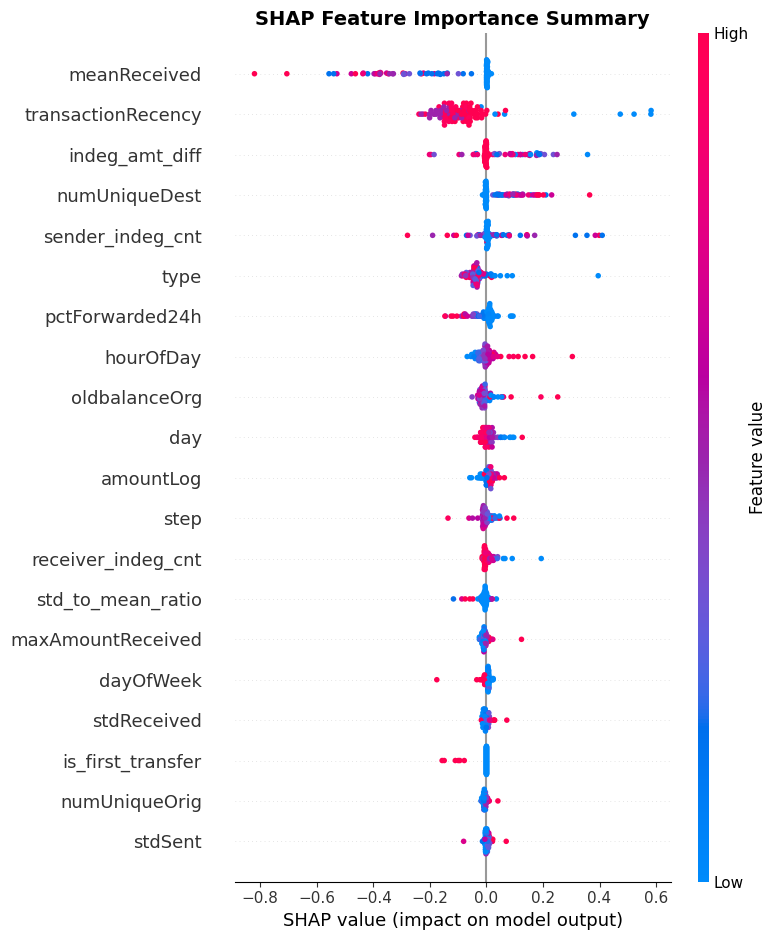

C:\Users\lylyl\AppData\Local\Temp\ipykernel_4304\170196917.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features,


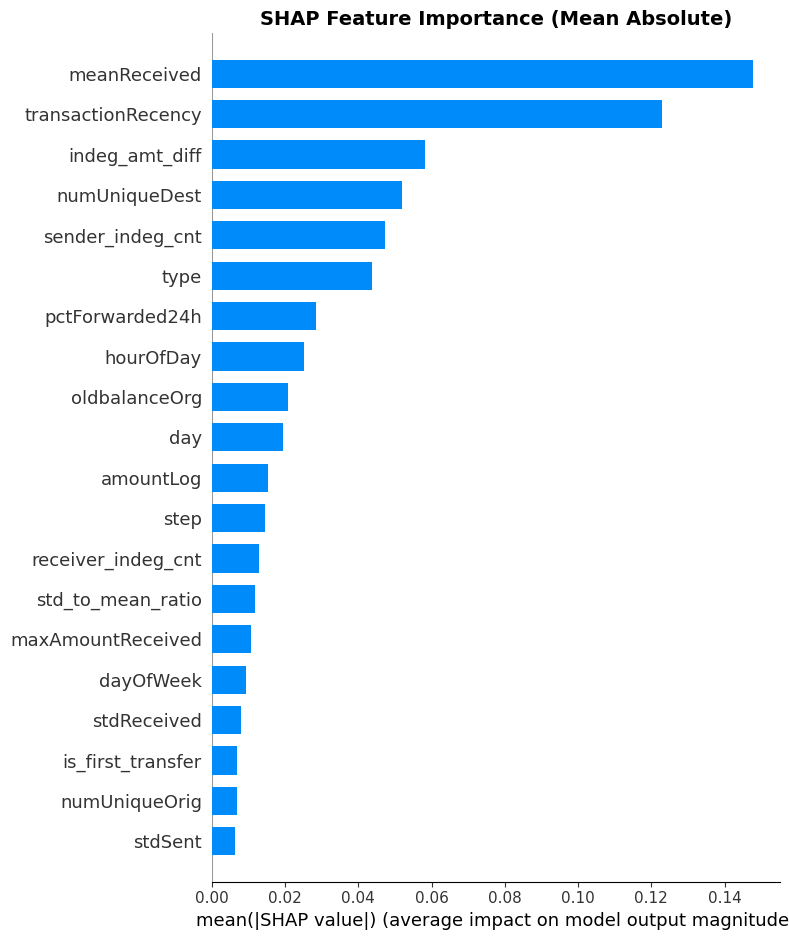


Top 20 Features by SHAP Importance:
           feature  shap_importance
      meanReceived         0.147746
transactionRecency         0.122938
    indeg_amt_diff         0.058197
     numUniqueDest         0.051916
  sender_indeg_cnt         0.047220
              type         0.043889
   pctForwarded24h         0.028581
         hourOfDay         0.025305
     oldbalanceOrg         0.020899
               day         0.019327
         amountLog         0.015357
              step         0.014543
receiver_indeg_cnt         0.013025
 std_to_mean_ratio         0.011818
 maxAmountReceived         0.010670
         dayOfWeek         0.009295
       stdReceived         0.008057
 is_first_transfer         0.006890
     numUniqueOrig         0.006841
           stdSent         0.006435


In [22]:
# ============================================================================
# VISUALIZE SHAP VALUES
# ============================================================================

# 1. Summary plot (shows feature importance and impact direction)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features, show=False)
plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Bar plot (average absolute SHAP values)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_use, X_sample, feature_names=selected_features, 
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean Absolute)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Feature importance DataFrame
shap_importance = pd.DataFrame({
    'feature': selected_features,
    'shap_importance': np.abs(shap_values_to_use).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("\nTop 20 Features by SHAP Importance:")
print(shap_importance.head(20).to_string(index=False))

In [24]:
all_features = pd.DataFrame({'feature': X_train_final.columns})

# Merge with all features, fill missing with 0
feature_importance_df = all_features.merge(shap_importance, on='feature', how='left').fillna(0)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('shap_importance', ascending=False)

# Calculate cumulative importance
feature_importance_df['cumulative_importance'] = (
    feature_importance_df['shap_importance'].cumsum() / feature_importance_df['shap_importance'].sum()
)

print(feature_importance_df.head(20))

top_features = feature_importance_df[
    feature_importance_df['cumulative_importance'] <= 0.95
]['feature'].tolist()

print(f"Selected {len(top_features)} features explaining 95% of model importance")
print(top_features)

               feature  shap_importance  cumulative_importance
15        meanReceived         0.147746               0.213429
25  transactionRecency         0.122938               0.391021
46      indeg_amt_diff         0.058197               0.475090
8        numUniqueDest         0.051916               0.550086
42    sender_indeg_cnt         0.047220               0.618297
1                 type         0.043889               0.681698
22     pctForwarded24h         0.028581               0.722986
2            hourOfDay         0.025305               0.759541
23       oldbalanceOrg         0.020899               0.789731
3                  day         0.019327               0.817651
4            amountLog         0.015357               0.839835
0                 step         0.014543               0.860844
44  receiver_indeg_cnt         0.013025               0.879658
21   std_to_mean_ratio         0.011818               0.896730
18   maxAmountReceived         0.010670               0

## Model Evaluation

In [25]:
# Set style
sns.set_style("whitegrid")

print("="*60)
print("PR-AUC AND F1-SCORE METRICS")
print("="*60)

# Get predictions (probabilities)
y_pred_proba = final_model.predict(X_test_scaled, verbose=0).flatten()

# Calculate Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Calculate F1-Score at default threshold (0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)
f1_default = f1_score(y_test, y_pred_default)
precision_default = precision_score(y_test, y_pred_default, zero_division=0)
recall_default = recall_score(y_test, y_pred_default, zero_division=0)

# Find optimal threshold (maximize F1-Score)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-7)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]



# Print results
print(f"\n{'='*60}")
print("METRICS SUMMARY")
print(f"{'='*60}")
print(f"\nPR-AUC (Average Precision): {pr_auc:.4f}")

print(f"\n{'='*60}")
print("F1-SCORE AT DEFAULT THRESHOLD (0.5)")
print(f"{'='*60}")
print(f"F1-Score:  {f1_default:.4f}")
print(f"Precision: {precision_default:.4f}")
print(f"Recall:    {recall_default:.4f}")

print(f"\n{'='*60}")
print("OPTIMAL F1-SCORE")
print(f"{'='*60}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"F1-Score:  {optimal_f1:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall:    {optimal_recall:.4f}")

PR-AUC AND F1-SCORE METRICS

METRICS SUMMARY

PR-AUC (Average Precision): 0.3729

F1-SCORE AT DEFAULT THRESHOLD (0.5)
F1-Score:  0.0402
Precision: 0.0207
Recall:    0.7500

OPTIMAL F1-SCORE
Optimal Threshold: 0.9878
F1-Score:  0.4241
Precision: 0.4935
Recall:    0.3718


C:\Users\lylyl\AppData\Local\Temp\ipykernel_4304\3927544202.py:26: RuntimeWarning: divide by zero encountered in divide
  y = f1_val * x / (2 * x - f1_val)


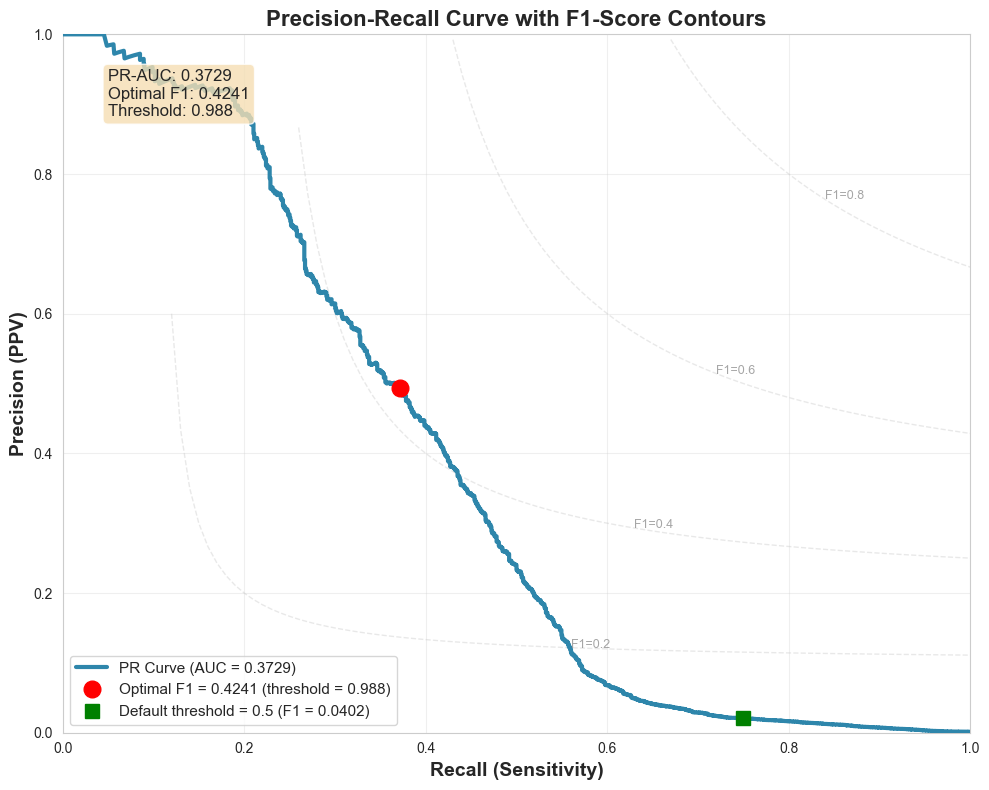

In [26]:
# ============================================================================
# 2. PRECISION-RECALL CURVE WITH F1 CONTOURS
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Plot PR curve
ax.plot(recall, precision, linewidth=3, label=f'PR Curve (AUC = {pr_auc:.4f})', 
        color='#2E86AB', zorder=3)


# Mark optimal F1 point
ax.plot(optimal_recall, optimal_precision, 'ro', markersize=12, 
        label=f'Optimal F1 = {optimal_f1:.4f} (threshold = {optimal_threshold:.3f})',
        zorder=4)

# Mark default threshold point
ax.plot(recall_default, precision_default, 'gs', markersize=10,
        label=f'Default threshold = 0.5 (F1 = {f1_default:.4f})',
        zorder=4)

# Add F1 contour lines
f1_values = np.array([0.2, 0.4, 0.6, 0.8])
for f1_val in f1_values:
    x = np.linspace(0.01, 1, 100)
    y = f1_val * x / (2 * x - f1_val)
    y[y < 0] = np.nan
    y[y > 1] = np.nan
    ax.plot(x, y, '--', color='lightgray', alpha=0.5, linewidth=1, zorder=0)
    # Add F1 label
    idx = np.where(~np.isnan(y))[0]
    if len(idx) > 0:
        mid_idx = len(idx) // 2
        ax.text(x[idx[mid_idx]], y[idx[mid_idx]], f'F1={f1_val:.1f}', 
               fontsize=9, color='gray', alpha=0.7)

ax.set_xlabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=14, fontweight='bold')
ax.set_title('Precision-Recall Curve with F1-Score Contours', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add text box with statistics
textstr = f'PR-AUC: {pr_auc:.4f}\nOptimal F1: {optimal_f1:.4f}\nThreshold: {optimal_threshold:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
# plt.savefig('pr_curve_with_f1.png', dpi=300, bbox_inches='tight')
plt.show()

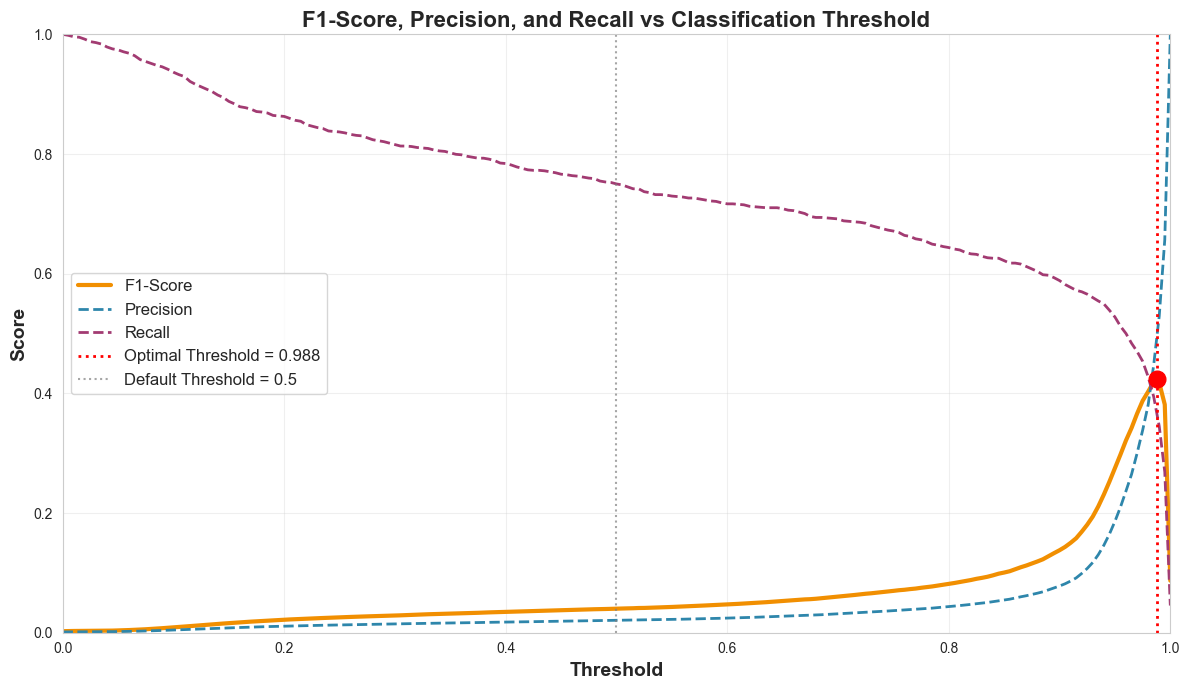

In [27]:
# ============================================================================
# 3. F1-SCORE VS THRESHOLD
# ============================================================================

# Calculate metrics across all thresholds
thresholds_to_test = np.linspace(0, 1, 201)
f1_scores_all = []
precision_scores = []
recall_scores = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    f1_scores_all.append(f1_score(y_test, y_pred_thresh, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_thresh, zero_division=0))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(thresholds_to_test, f1_scores_all, linewidth=3, 
        label='F1-Score', color='#F18F01')
ax.plot(thresholds_to_test, precision_scores, linewidth=2, 
        label='Precision', color='#2E86AB', linestyle='--')
ax.plot(thresholds_to_test, recall_scores, linewidth=2, 
        label='Recall', color='#A23B72', linestyle='--')

# Mark optimal F1
ax.axvline(x=optimal_threshold, color='red', linestyle=':', linewidth=2, 
           label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax.plot(optimal_threshold, optimal_f1, 'ro', markersize=12)

# Mark default threshold
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, 
           label='Default Threshold = 0.5', alpha=0.7)

ax.set_xlabel('Threshold', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('F1-Score, Precision, and Recall vs Classification Threshold', 
             fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
# plt.savefig('f1_vs_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# ============================================================================
# 4. DETAILED THRESHOLD ANALYSIS TABLE
# ============================================================================

print(f"\n{'='*60}")
print("DETAILED THRESHOLD ANALYSIS")
print(f"{'='*60}")

# Analyze specific thresholds
analysis_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
analysis_results = []

for thresh in analysis_thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    tp = np.sum((y_test == 1) & (y_pred_thresh == 1))
    tn = np.sum((y_test == 0) & (y_pred_thresh == 0))
    fp = np.sum((y_test == 0) & (y_pred_thresh == 1))
    fn = np.sum((y_test == 1) & (y_pred_thresh == 0))
    
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    analysis_results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'Frauds Detected': tp,
        'False Alarms': fp
    })

analysis_df = pd.DataFrame(analysis_results)
print("\n" + analysis_df.to_string(index=False))

# Highlight optimal threshold
optimal_row = analysis_df.iloc[(analysis_df['Threshold'] - optimal_threshold).abs().argsort()[0]]
print(f"\n{'='*60}")
print(f"RECOMMENDED THRESHOLD: {optimal_threshold:.3f}")
print(f"{'='*60}")
print(f"This threshold maximizes F1-Score = {optimal_f1:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall: {optimal_recall:.4f}")


DETAILED THRESHOLD ANALYSIS

 Threshold  Precision   Recall  F1-Score   TP     TN     FP  FN  Frauds Detected  False Alarms
       0.1   0.004478 0.936688  0.008914 1154 696618 256543  78             1154        256543
       0.2   0.011016 0.862825  0.021755 1063 857732  95429 169             1063         95429
       0.3   0.014667 0.815747  0.028816 1005 885645  67516 227             1005         67516
       0.4   0.017812 0.784091  0.034833  966 899895  53266 266              966         53266
       0.5   0.020654 0.750000  0.040200  924 909347  43814 308              924         43814
       0.6   0.024433 0.716721  0.047255  883 917904  35257 349              883         35257
       0.7   0.031575 0.691558  0.060393  852 927030  26131 380              852         26131
       0.8   0.043588 0.643669  0.081647  793 935761  17400 439              793         17400
       0.9   0.078075 0.588474  0.137859  725 944600   8561 507              725          8561

RECOMMENDED THRESHO

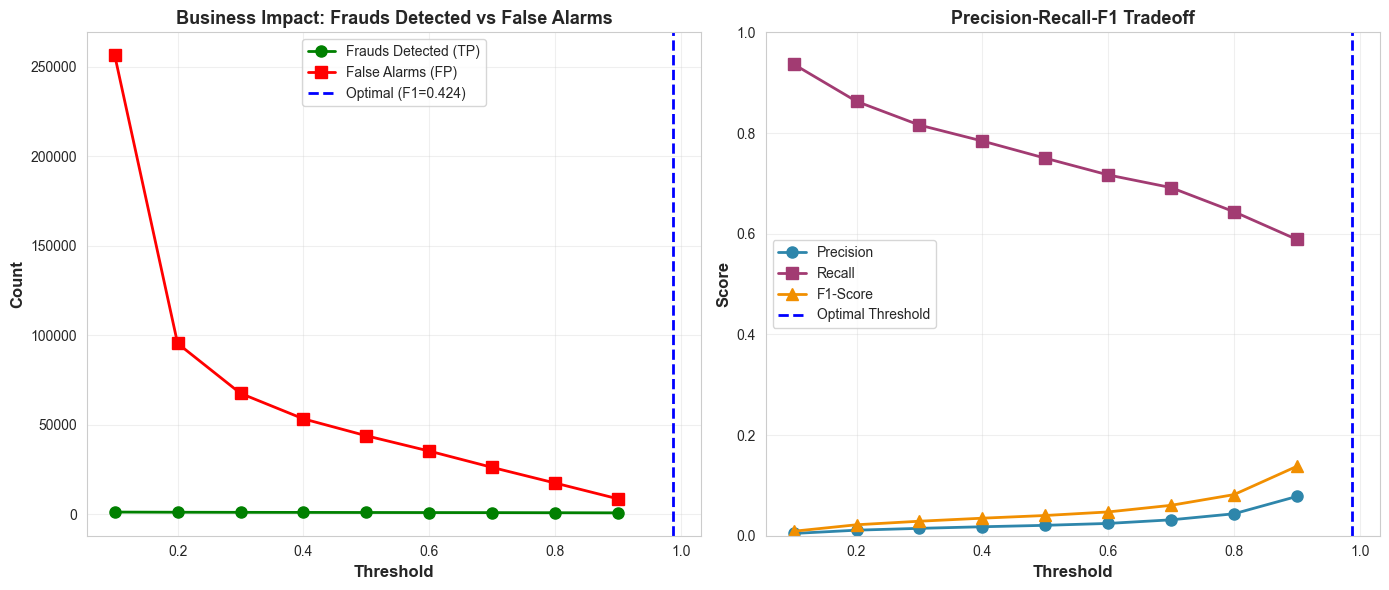

In [29]:
# ============================================================================
# 5. BUSINESS IMPACT VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Frauds detected vs False alarms
axes[0].plot(analysis_df['Threshold'], analysis_df['Frauds Detected'], 
             'o-', linewidth=2, markersize=8, color='green', label='Frauds Detected (TP)')
axes[0].plot(analysis_df['Threshold'], analysis_df['False Alarms'], 
             's-', linewidth=2, markersize=8, color='red', label='False Alarms (FP)')
axes[0].axvline(x=optimal_threshold, color='blue', linestyle='--', linewidth=2, 
                label=f'Optimal (F1={optimal_f1:.3f})')
axes[0].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Business Impact: Frauds Detected vs False Alarms', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Precision-Recall tradeoff
axes[1].plot(analysis_df['Threshold'], analysis_df['Precision'], 
             'o-', linewidth=2, markersize=8, color='#2E86AB', label='Precision')
axes[1].plot(analysis_df['Threshold'], analysis_df['Recall'], 
             's-', linewidth=2, markersize=8, color='#A23B72', label='Recall')
axes[1].plot(analysis_df['Threshold'], analysis_df['F1-Score'], 
             '^-', linewidth=2, markersize=8, color='#F18F01', label='F1-Score')
axes[1].axvline(x=optimal_threshold, color='blue', linestyle='--', linewidth=2, 
                label=f'Optimal Threshold')
axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall-F1 Tradeoff', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
# plt.savefig('business_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================================
# 8. SAVE RESULTS TO CSV
# ============================================================================

# # Save threshold analysis
# analysis_df.to_csv('threshold_analysis.csv', index=False)
# print(f"\n✓ Threshold analysis saved to 'threshold_analysis.csv'")

# # Save summary metrics
# summary_metrics = {
#     'Metric': ['PR-AUC', 'F1 (default)', 'F1 (optimal)', 
#                'Optimal Threshold', 'Precision (optimal)', 'Recall (optimal)'],
#     'Value': [pr_auc, f1_default, optimal_f1, 
#               optimal_threshold, optimal_precision, optimal_recall]
# }
# summary_df = pd.DataFrame(summary_metrics)
# summary_df.to_csv('pr_auc_f1_summary.csv', index=False)
# print(f"✓ Summary metrics saved to 'pr_auc_f1_summary.csv'")

In [31]:
## Save Model
import os

os.makedirs('../models/NN/', exist_ok=True)
final_model.save('../models/NN/NN_1to5_all.keras')

In [32]:
# from keras.models import load_model
# model = load_model('../models/NN/NN_1to5_all.keras')